In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

* Numerical
* Categorical
* Date Time

In [38]:
np.random.seed(42)

n = 150

departments = np.random.choice(
    ["Data Science", "Analytics", "Finance", "HR", "Marketing"],
    size=n,
    p=[0.25, 0.25, 0.20, 0.15, 0.15]
)

gender = np.random.choice(
    ["Male", "Female"],
    size=n,
    p=[0.55, 0.45]
)

education = np.random.choice(
    ["Bachelor's", "Master's", "PhD"],
    size=n,
    p=[0.50, 0.40, 0.10]
)

employment_type = np.random.choice(
    ["Full Time", "Part Time", "Contract"],
    size=n,
    p=[0.70, 0.15, 0.15]
)

age = np.random.normal(31, 6, n).round().astype(int)
age = np.clip(age, 21, 50)

experience = np.maximum(
    0,
    age - 22 + np.random.normal(0, 2, n)
).round(1)

salary = (
    35000
    + experience * 4500
    + np.random.normal(0, 12000, n)
)
salary = np.maximum(salary, 28000).round(0)

performance = (
    5.8
    + experience * 0.12
    + np.random.normal(0, 1.1, n)
)
performance = np.clip(performance, 1, 10).round(1)

projects = np.maximum(
    1,
    experience * 0.7 + np.random.normal(4, 2.5, n)
).round().astype(int)

joining_dates = pd.date_range(
    start="2019-01-01",
    end="2025-12-01",
    periods=n
)

df = pd.DataFrame({
    "Department": departments,
    "Gender": gender,
    "Education": education,
    "Employment Type": employment_type,
    "Age": age,
    "Experience": experience,
    "Salary": salary,
    "Performance Score": performance,
    "Projects Completed": projects,
    "Joining Date": joining_dates
})

df.head()


,Department,Gender,Education,Employment Type,Age,Experience,Salary,Performance Score,Projects Completed,Joining Date
0,Analytics,Female,Bachelor's,Part Time,28,6.8,54207.0,6.8,7,2019-01-01 00:00:00.000000000
1,Marketing,Male,Master's,Full Time,26,7.8,101689.0,6.8,8,2019-01-17 22:52:20.939597315
2,HR,Male,Master's,Full Time,30,6.5,70170.0,5.1,8,2019-02-03 21:44:41.879194631
3,Finance,Male,Master's,Contract,25,0.5,39468.0,6.7,7,2019-02-20 20:37:02.818791946
4,Data Science,Female,Master's,Full Time,28,2.4,35500.0,6.8,7,2019-03-09 19:29:23.758389262


In [39]:
df.shape

(150, 10)

In [40]:
df.describe()

,Age,Experience,Salary,Performance Score,Projects Completed,Joining Date
count,150.000000,150.000000,150.000000,150.000000,150.000000,150
mean,30.586667,8.598667,76421.620000,6.961333,10.206667,2022-06-17 00:00:00.000000256
min,21.000000,0.000000,28000.000000,3.700000,1.000000,2019-01-01 00:00:00
25%,26.000000,4.525000,56253.500000,6.100000,7.000000,2020-09-23 12:00:00
50%,30.000000,7.900000,73668.500000,7.000000,10.000000,2022-06-17 00:00:00
75%,34.000000,12.075000,92880.500000,7.800000,13.000000,2024-03-09 12:00:00
max,49.000000,27.100000,156057.000000,10.000000,27.000000,2025-12-01 00:00:00
std,5.645200,5.787559,27868.279172,1.334206,4.763250,NaN


In [41]:
df.describe(include='O')

,Department,Gender,Education,Employment Type
count,150,150,150,150
unique,5,2,3,3
top,Data Science,Female,Bachelor's,Full Time
freq,42,76,74,103


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Department          150 non-null    object        
 1   Gender              150 non-null    object        
 2   Education           150 non-null    object        
 3   Employment Type     150 non-null    object        
 4   Age                 150 non-null    int64         
 5   Experience          150 non-null    float64       
 6   Salary              150 non-null    float64       
 7   Performance Score   150 non-null    float64       
 8   Projects Completed  150 non-null    int64         
 9   Joining Date        150 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 11.8+ KB


# Univariate Analysis

**Numerical**

* Histogram + kde
* Box Plot
* Violin plot

**Category**
* Bar
* Pie chart

## Histogram

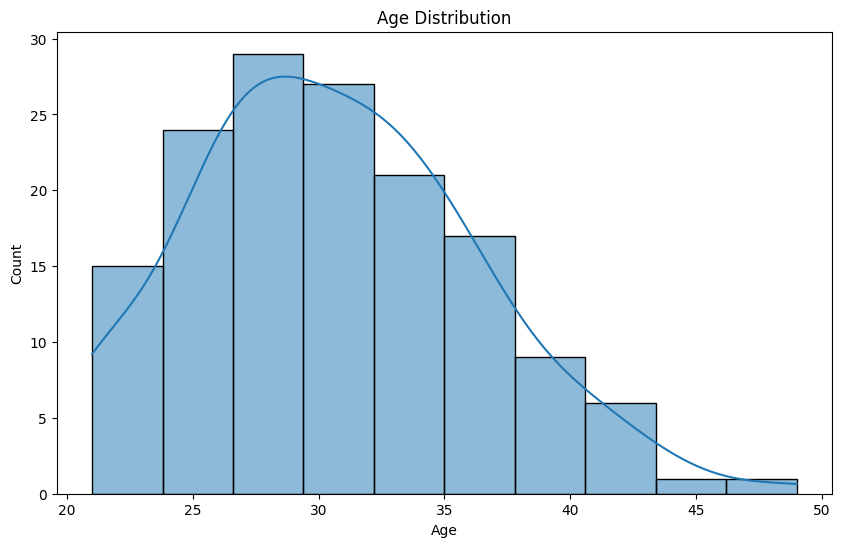

In [43]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'],kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

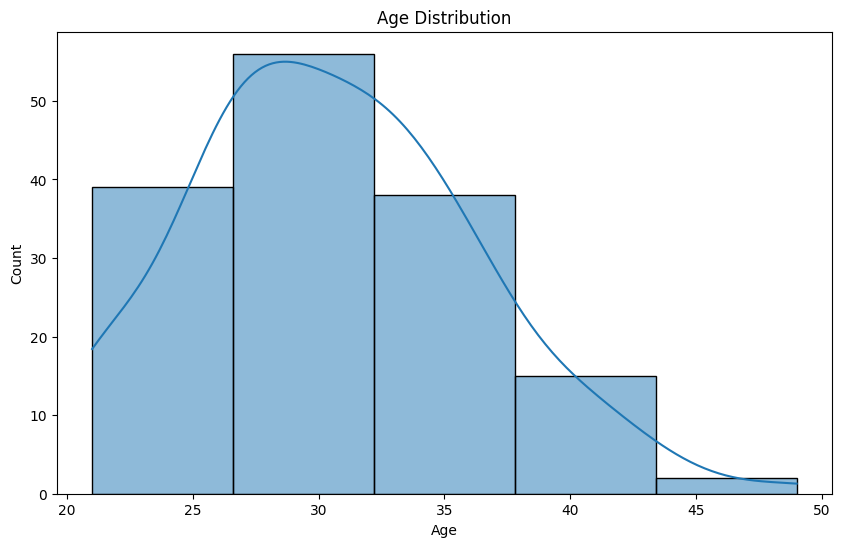

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'],kde=True,bins=5)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

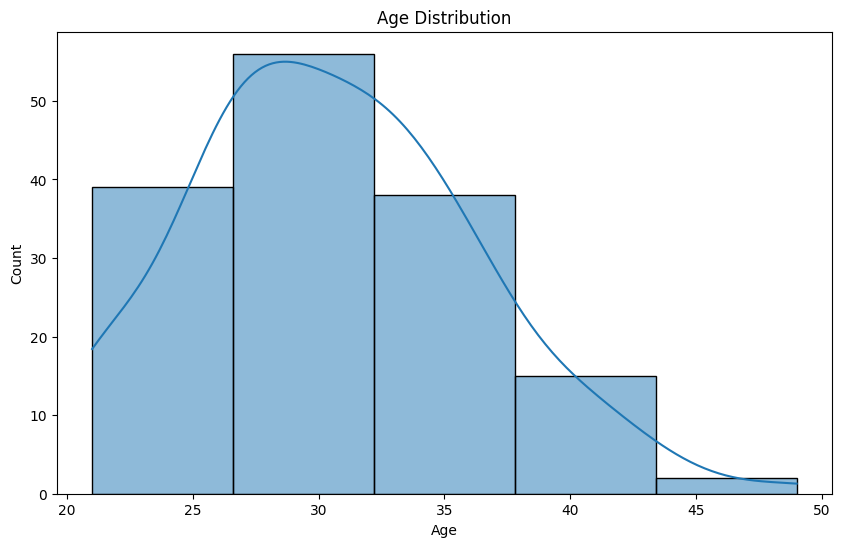

In [45]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df,x='Age',kde=True,bins=5)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

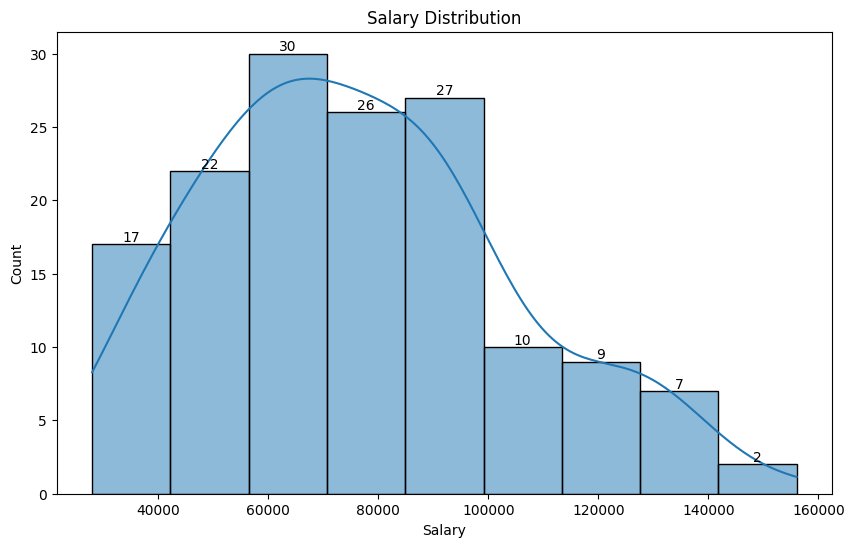

In [86]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df,x='Salary',kde=True,bins=9)
ax.bar_label(ax.containers[0])
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.show()

## Box Plot

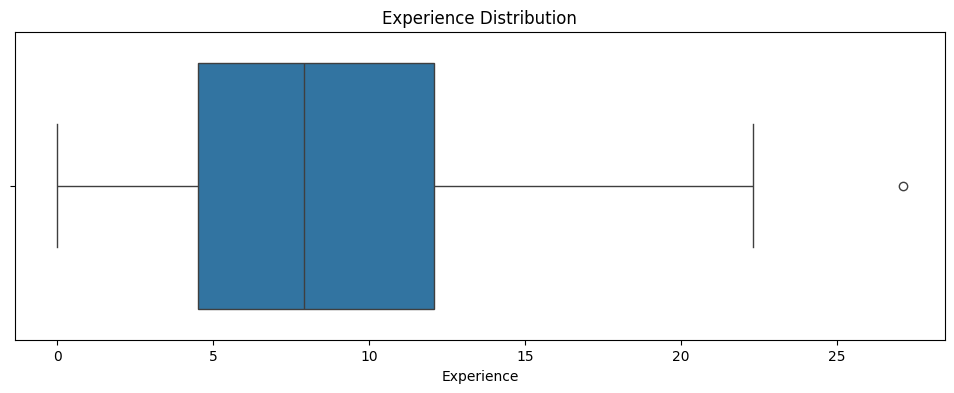

In [46]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=df,x='Experience')
plt.title("Experience Distribution")
plt.xlabel("Experience")
plt.show()

## Violin Plot

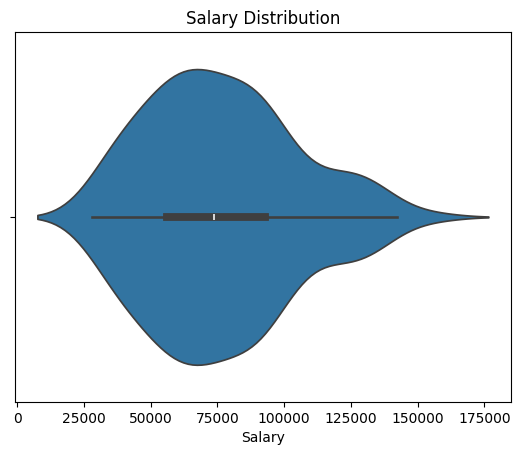

In [78]:
sns.violinplot(data=df,x='Salary')
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.show()

In [48]:
df.columns

Index(['Department', 'Gender', 'Education', 'Employment Type', 'Age',
       'Experience', 'Salary', 'Performance Score', 'Projects Completed',
       'Joining Date'],
      dtype='object')

## Bar Chart

In [49]:
department = df['Department'].value_counts()

In [50]:
department

,count
Department,
Data Science,42
Analytics,38
Finance,25
HR,23
Marketing,22


In [51]:
department.values

array([42, 38, 25, 23, 22])

In [52]:
department.index

Index(['Data Science', 'Analytics', 'Finance', 'HR', 'Marketing'], dtype='object', name='Department')

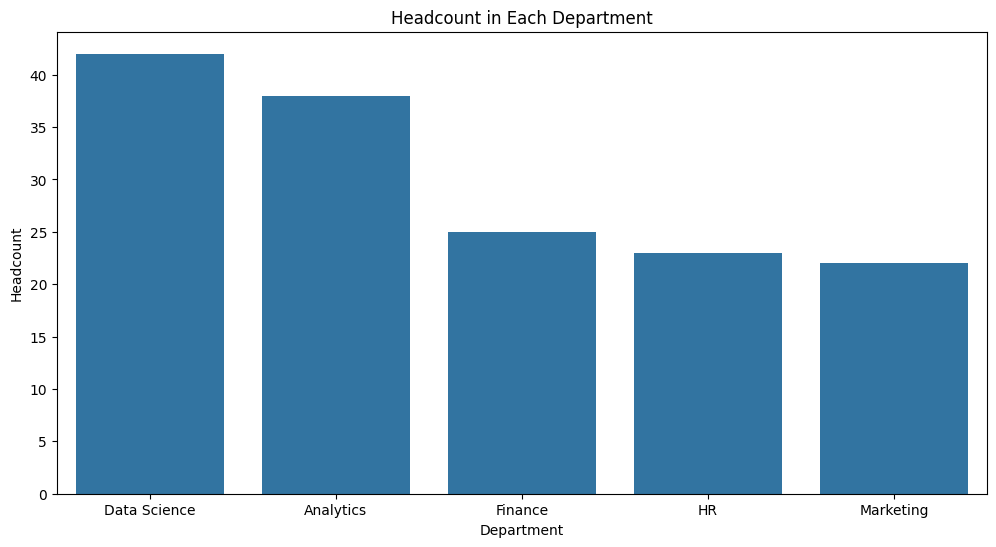

In [53]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df['Department'].value_counts().index,
            y=df['Department'].value_counts().values)
plt.title("Headcount in Each Department")
plt.xlabel("Department")
plt.ylabel("Headcount")
plt.show()

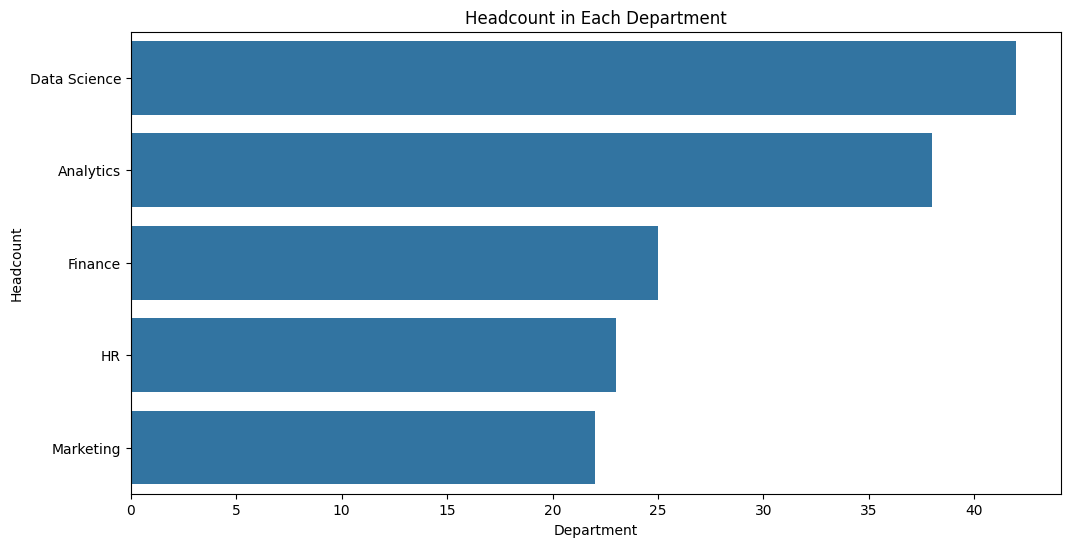

In [54]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df['Department'].value_counts().values,
            y=df['Department'].value_counts().index)
plt.title("Headcount in Each Department")
plt.xlabel("Department")
plt.ylabel("Headcount")
plt.show()

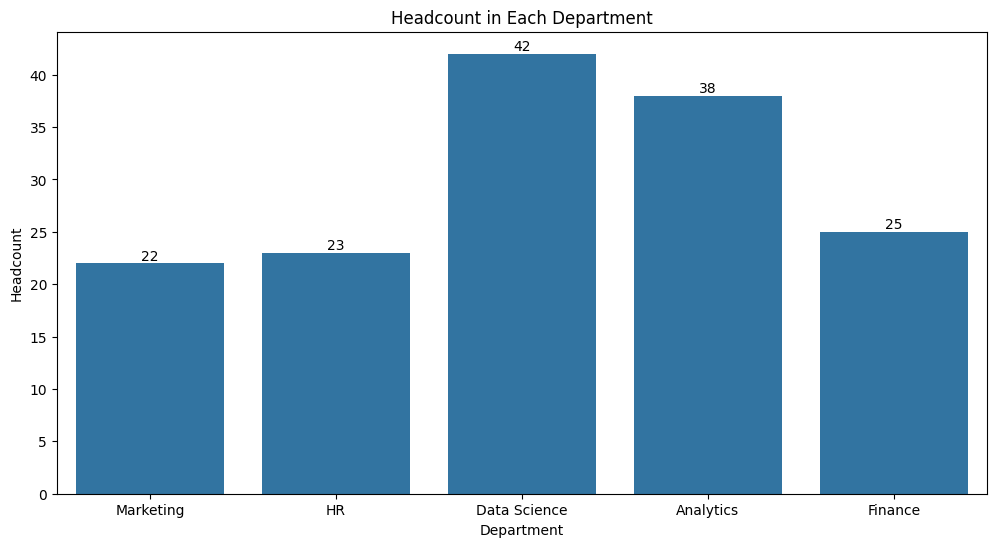

In [75]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=df['Department'].value_counts().index,
            y=df['Department'].value_counts().values,
                 order=['Marketing','HR','Data Science', 'Analytics', 'Finance'])
ax.bar_label(ax.containers[0])
plt.title("Headcount in Each Department")
plt.xlabel("Department")
plt.ylabel("Headcount")
plt.show()

## Pie Chart

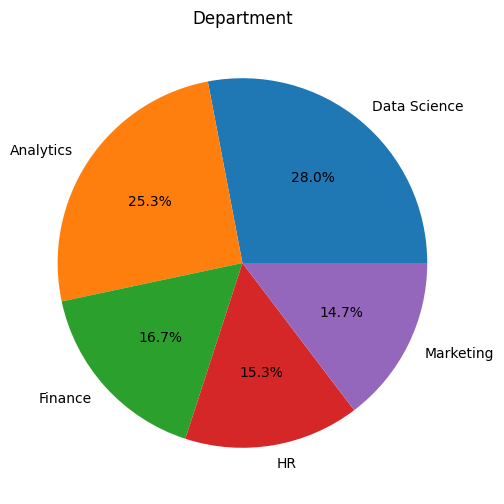

In [56]:
plt.figure(figsize=(12, 6))
plt.pie(x=df['Department'].value_counts().values,
        labels=df['Department'].value_counts().index,
        autopct='%1.1f%%')
plt.title("Department")
plt.show()

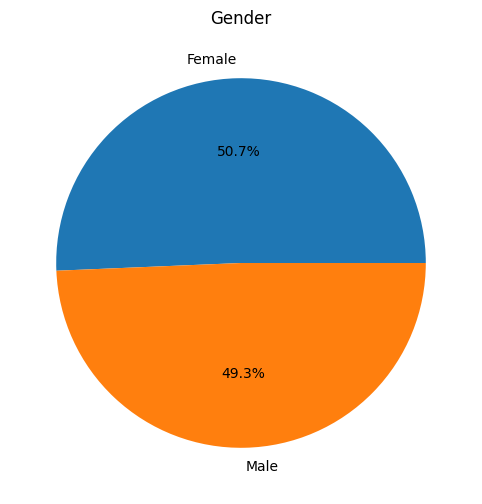

In [57]:
plt.figure(figsize=(12, 6))
plt.pie(x=df['Gender'].value_counts().values,
        labels=df['Gender'].value_counts().index,
        autopct='%1.1f%%')
plt.title("Gender")
plt.show()

# Bi-Variate

**Bivariate = two variables**

Reference:

| Variable Combination | Chart / Technique | Purpose |
|---|---|---|
| Numerical + Numerical | Scatter | Relationship / pattern |
| Numerical + Numerical | Correlation | Strength + direction |
| Numerical + Numerical | Line | Trend when X is ordered |
| Numerical + Categorical | Boxplot | Compare distributions |
| Numerical + Categorical | Violin | Compare distributions + density |
| Numerical + Categorical | Bar | Compare aggregate values |
| Numerical + Categorical | Strip / Swarm | Individual observations |
| Categorical + Categorical | Grouped bar | Compare categories |
| Categorical + Categorical | Stacked bar | Composition |
| Categorical + Categorical | 100% stacked bar | Proportion |
| Categorical + Categorical | Crosstab | Frequency relationship |
| Date/Time + Numerical | Line | Trend over time |
| Date/Time + Numerical | Bar | Compare time periods |


In [58]:
df.columns

Index(['Department', 'Gender', 'Education', 'Employment Type', 'Age',
       'Experience', 'Salary', 'Performance Score', 'Projects Completed',
       'Joining Date'],
      dtype='object')

## Scatter Plot

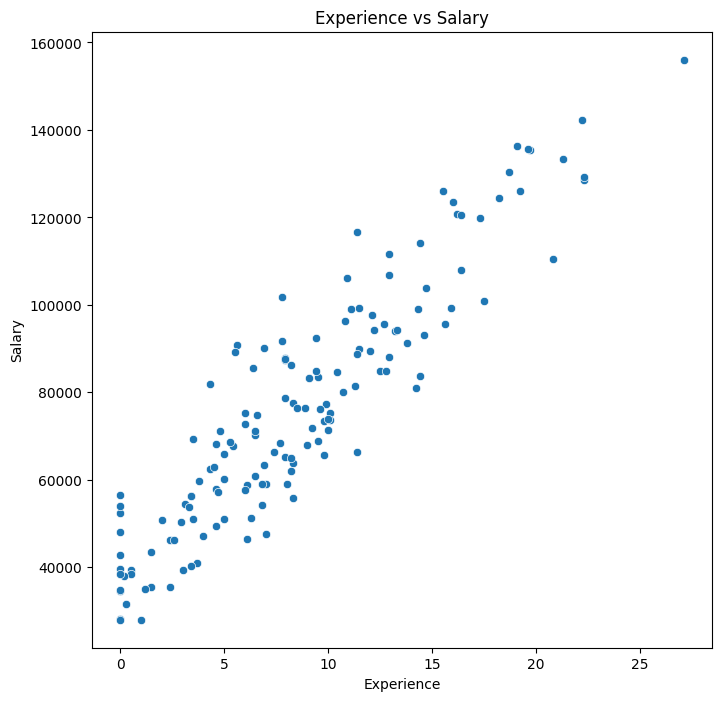

In [59]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df,x='Experience',y='Salary')
plt.title("Experience vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.show()

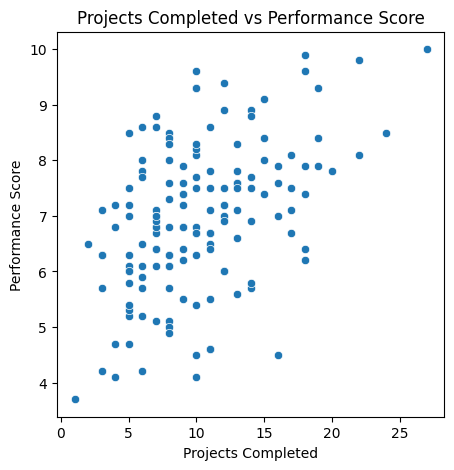

In [60]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df,x='Projects Completed',y='Performance Score')
plt.title("Projects Completed vs Performance Score")
plt.xlabel("Projects Completed")
plt.ylabel("Performance Score")
plt.show()

## Correlation

In [61]:
df['Projects Completed'].corr(df['Performance Score'])

np.float64(0.46772640793841325)

## LineChart

In [62]:
df['Age'].value_counts()

,count
Age,
28,14
26,13
33,12
36,11
30,10
31,10
21,10
34,9
25,8


In [63]:
df[['Age','Salary']]

,Age,Salary
0,28,54207.0
1,26,101689.0
2,30,70170.0
3,25,39468.0
4,28,35500.0
...,...,...
145,33,62097.0
146,36,94324.0
147,25,31630.0
148,36,89345.0


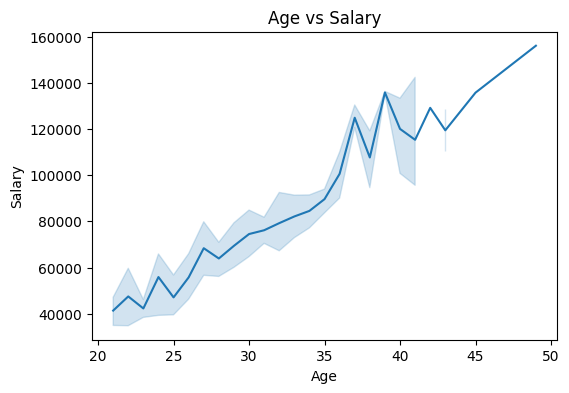

In [64]:
plt.figure(figsize=(6, 4))
sns.lineplot(data=df,x='Age',y='Salary')
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

In [65]:
experience = df.groupby('Age',as_index=False)['Salary'].mean()
experience

,Age,Salary
0,21,41351.600000
1,22,47487.000000
2,23,42280.000000
3,24,55879.333333
4,25,47069.875000
5,26,55735.000000
6,27,68368.428571
7,28,63921.928571
8,29,69401.250000
9,30,74503.100000


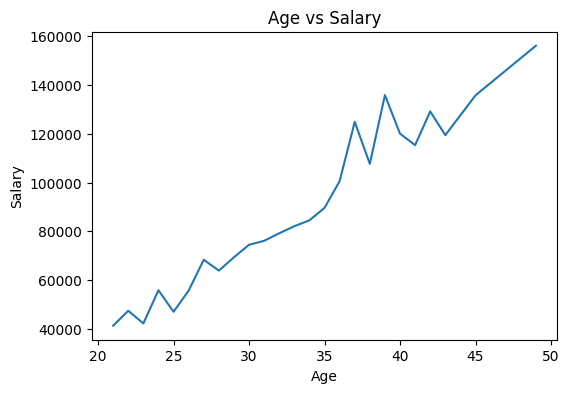

In [66]:
plt.figure(figsize=(6, 4))
sns.lineplot(data=experience,x='Age',y='Salary')
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

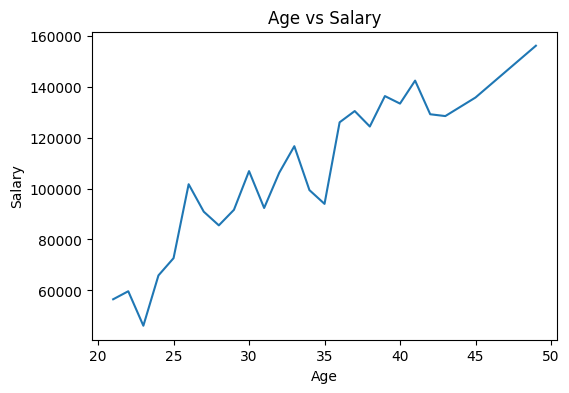

In [67]:
experience2 = df.groupby('Age',as_index=False)['Salary'].max()
plt.figure(figsize=(6, 4))
sns.lineplot(data=experience2,x='Age',y='Salary')
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

## Box-Plot with Category

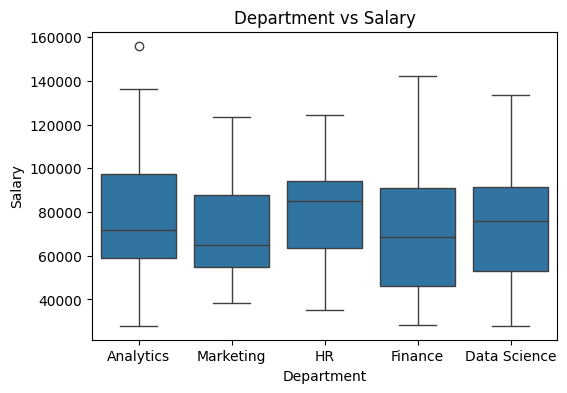

In [68]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df,x='Department',y='Salary')
plt.title("Department vs Salary")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.show()

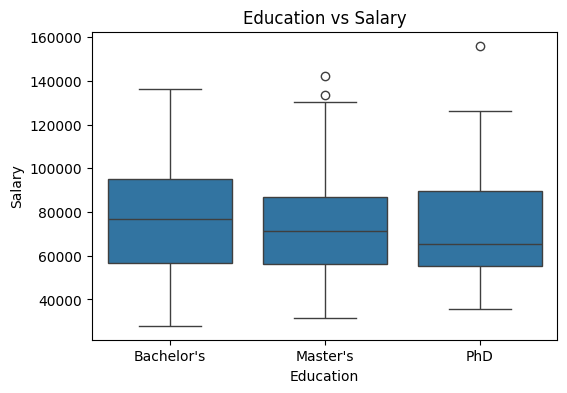

In [69]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df,x='Education',y='Salary')
plt.title("Education vs Salary")
plt.xlabel("Education")
plt.ylabel("Salary")
plt.show()

## Violin Chart with Cat

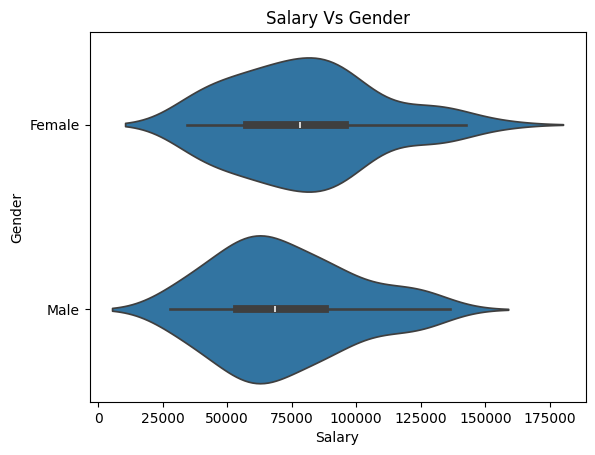

In [79]:
#plt.figure(figsize=(5, 12))
sns.violinplot(data=df,x='Salary',y='Gender')
plt.title("Salary Vs Gender")
plt.xlabel("Salary")
plt.ylabel("Gender")
plt.show()

**Bivariate = two variables**

Reference:

| Variable Combination | Chart / Technique | Purpose |
|---|---|---|
| Numerical + Numerical | Scatter | Relationship / pattern |
| Numerical + Numerical | Correlation | Strength + direction |
| Numerical + Numerical | Line | Trend when X is ordered |
| Numerical + Categorical | Boxplot | Compare distributions |
| Numerical + Categorical | Violin | Compare distributions + density |
| Numerical + Categorical | Bar | Compare aggregate values |
| Numerical + Categorical | Strip / Swarm | Individual observations |
| Categorical + Categorical | Grouped bar | Compare categories |
| Categorical + Categorical | Stacked bar | Composition |
| Categorical + Categorical | 100% stacked bar | Proportion |
| Categorical + Categorical | Crosstab | Frequency relationship |
| Date/Time + Numerical | Line | Trend over time |
| Date/Time + Numerical | Bar | Compare time periods |


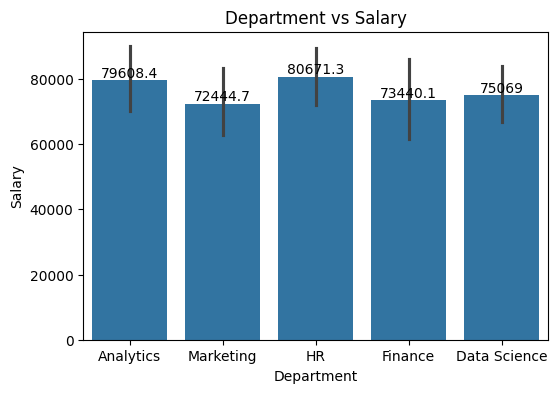

In [71]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df,x='Department',y='Salary')
ax.bar_label(ax.containers[0])
plt.title("Department vs Salary")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.show()
#

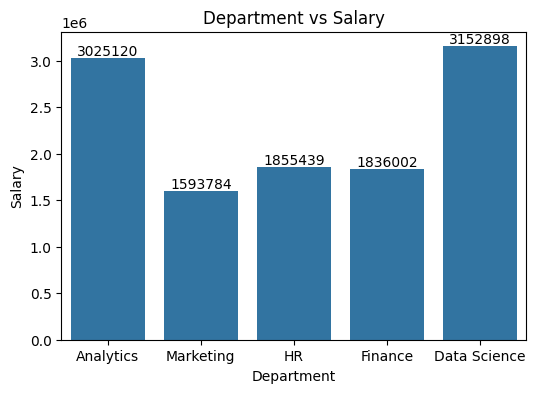

In [85]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=df,
                 x='Department',
                 y='Salary',
                 estimator='sum',
                 errorbar=None)
ax.bar_label(ax.containers[0],fmt='%d')
plt.title("Department vs Salary")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.show()
#

## Strip Chart

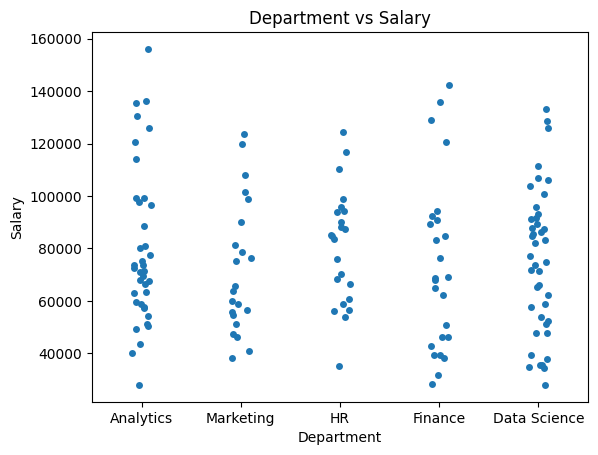

In [87]:
sns.stripplot(data=df,x='Department',y='Salary')
plt.title("Department vs Salary")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.show()

#Swarm Plot

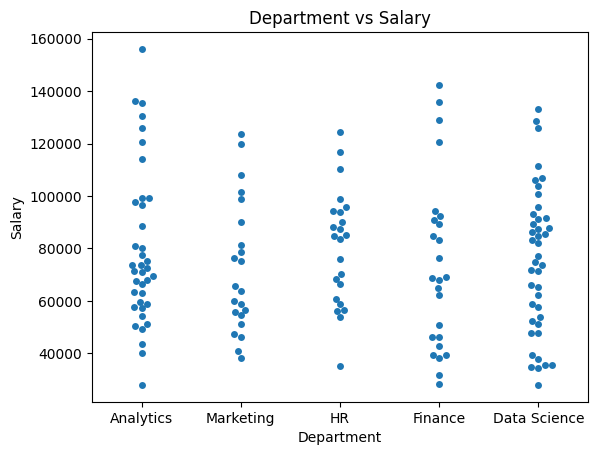

In [88]:
sns.swarmplot(data=df,x='Department',y='Salary')
plt.title("Department vs Salary")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.show()

Cat vs Cat

## Cross Tab

In [89]:
pd.crosstab(df['Department'],df['Gender'])

Gender,Female,Male
Department,,
Analytics,19,19
Data Science,22,20
Finance,8,17
HR,13,10
Marketing,14,8


In [92]:
Emp_typebyDep = pd.crosstab(df['Department'],df['Employment Type'])
Emp_typebyDep

Employment Type,Contract,Full Time,Part Time
Department,,,
Analytics,8,26,4
Data Science,11,28,3
Finance,7,18,0
HR,3,15,5
Marketing,3,16,3


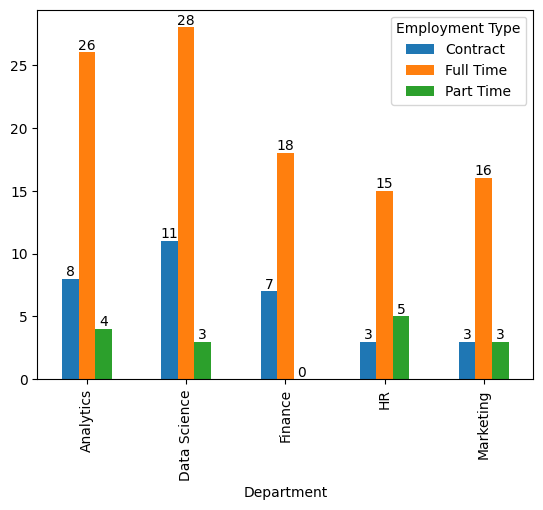

In [102]:
ax = Emp_typebyDep.plot(kind='bar')

for containers in ax.containers:
    ax.bar_label(containers)
plt.show()

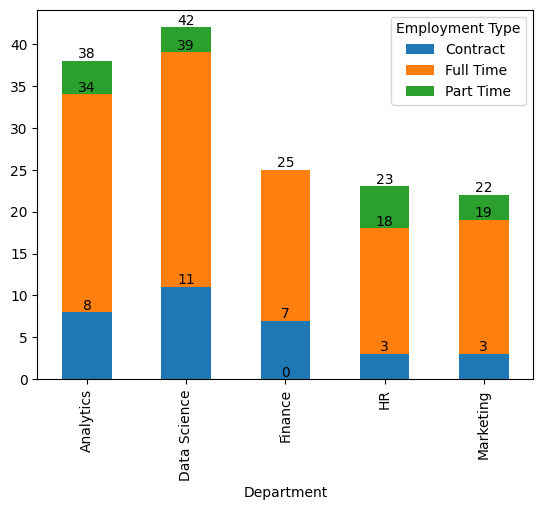

In [105]:
ax = Emp_typebyDep.plot(kind='bar',stacked=True)

for containers in ax.containers:
    ax.bar_label(containers)
plt.show()

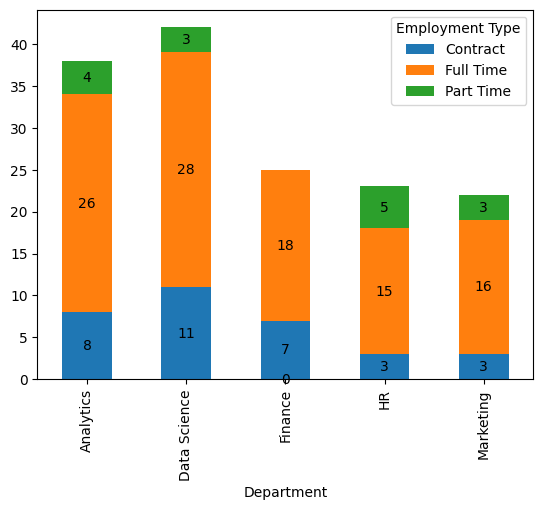

In [104]:
ax = Emp_typebyDep.plot(kind='bar',stacked=True)

for containers in ax.containers:
    ax.bar_label(containers,label_type='center')
plt.show()

In [109]:
Emp_typebyDep2 = pd.crosstab(df['Department'],df['Employment Type'],normalize='index')*100
Emp_typebyDep2

Employment Type,Contract,Full Time,Part Time
Department,,,
Analytics,21.052632,68.421053,10.526316
Data Science,26.190476,66.666667,7.142857
Finance,28.000000,72.000000,0.000000
HR,13.043478,65.217391,21.739130
Marketing,13.636364,72.727273,13.636364


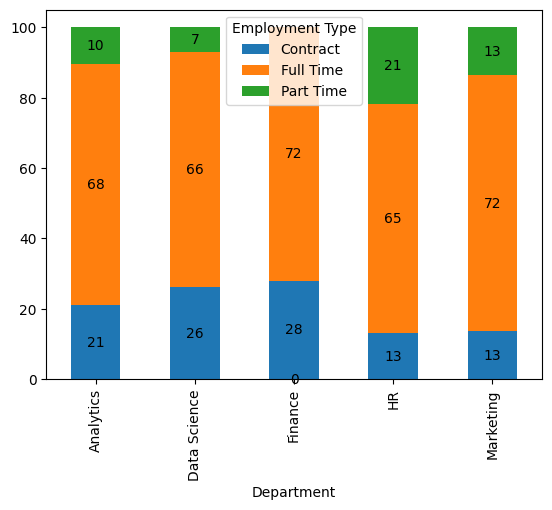

In [113]:
ax = Emp_typebyDep2.plot(kind='bar',stacked=True)

for containers in ax.containers:
    ax.bar_label(containers,label_type='center',fmt='%d')
plt.show()

#Date vs Number


Joining Date

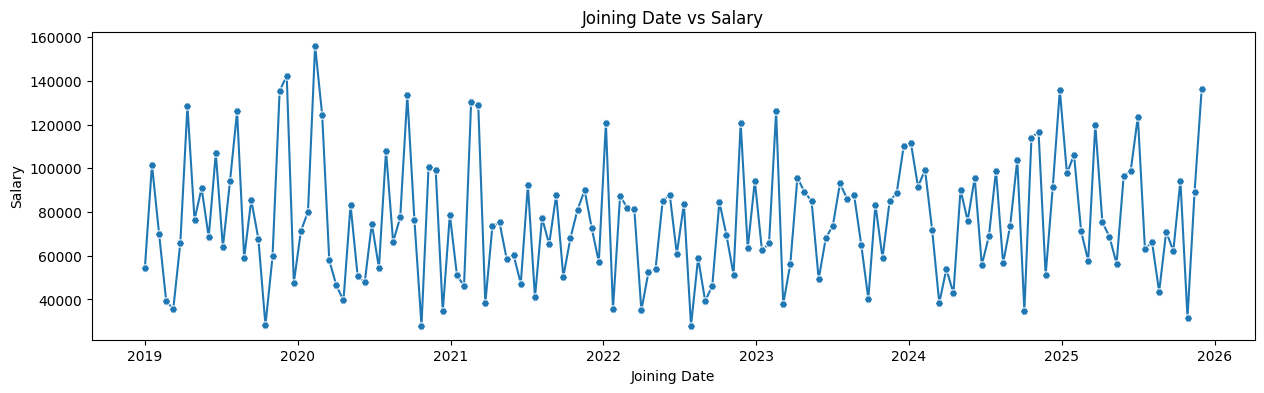

In [129]:
plt.figure(figsize=(15, 4))
sns.lineplot(data=df,x='Joining Date',y='Salary',marker='H')
plt.title("Joining Date vs Salary")
plt.xlabel("Joining Date")
plt.ylabel("Salary")
plt.show()

In [132]:
df['Joining year'] = df['Joining Date'].dt.year

In [133]:
Joined_year = df.groupby('Joining year',as_index=False)['Salary'].mean()
Joined_year

,Joining year,Salary
0,2019,79438.272727
1,2020,76814.045455
2,2021,71108.428571
3,2022,69195.500000
4,2023,76556.380952
5,2024,80579.227273
6,2025,81484.350000


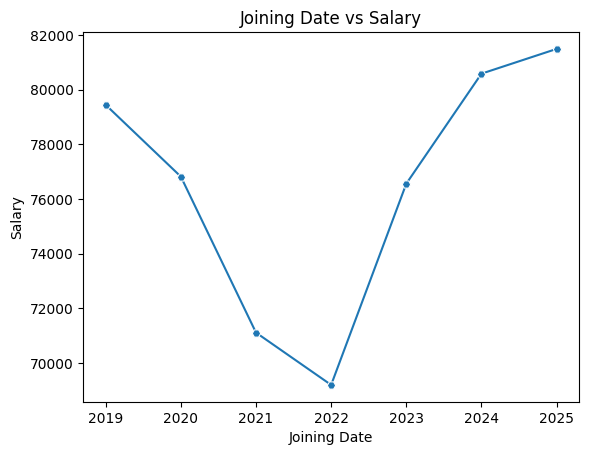

In [134]:
sns.lineplot(data=Joined_year,x='Joining year',y='Salary',marker='H')
plt.title("Joining Date vs Salary")
plt.xlabel("Joining Date")
plt.ylabel("Salary")
plt.show()

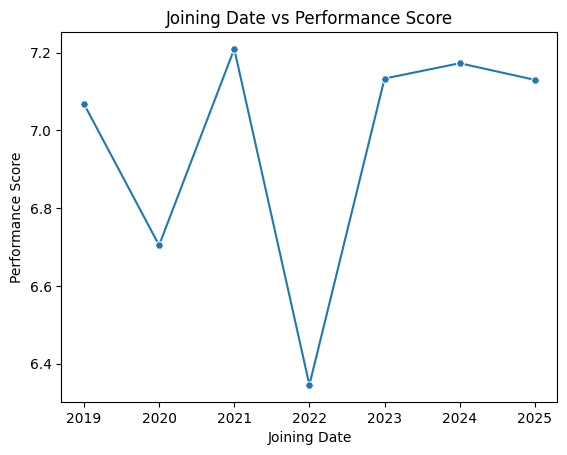

In [136]:
performance_year = df.groupby('Joining year',as_index=False)['Performance Score'].mean()

sns.lineplot(data=performance_year,x='Joining year',y='Performance Score',marker='H')
plt.title("Joining Date vs Performance Score")
plt.xlabel("Joining Date")
plt.ylabel("Performance Score")
plt.show()